In [19]:
import sys
print(sys.executable)
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

/Users/mac/Desktop/Readmission-risk-predictor/venv/bin/python


In [20]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [21]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_val = pd.read_csv("../data/processed/X_val.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [22]:
log_model = LogisticRegression(
    max_iter=2750,
    class_weight="balanced",
    random_state=42
)
log_model.fit(X_train, y_train)
print("Logistic Regression iterations used:", log_model.n_iter_)

Logistic Regression iterations used: [2698]


In [23]:

y_val_prob = log_model.predict_proba(X_val)[:,1]

#predictions with threshold =0.5
y_pred_50 = (y_val_prob >= 0.50).astype(int)
#predictions with threshold = 0.40
y_pred_40 = (y_val_prob >= 0.40).astype(int)


In [24]:
print("Logistic Regression (Threshold =0.50)")
print("Accuracy:", accuracy_score(y_val,y_pred_50))
print("Precision:",precision_score(y_val,y_pred_50))
print("Recall:", recall_score(y_val,y_pred_50))
print("F1 Score:", f1_score(y_val,y_pred_50))
print("ROC-AUC:", roc_auc_score(y_val,y_val_prob))

Logistic Regression (Threshold =0.50)
Accuracy: 0.6520571278825996
Precision: 0.1698389458272328
Recall: 0.544920728126835
F1 Score: 0.2589646993163109
ROC-AUC: 0.6443502300970759


In [25]:
print("Logistic Regression (Threshold = 0.40)")
print("Accuracy:", accuracy_score(y_val,y_pred_40))
print("Precision:",precision_score(y_val,y_pred_40))
print("Recall:", recall_score(y_val,y_pred_40))
print("F1 Score:", f1_score(y_val,y_pred_40))
print("ROC-AUC:", roc_auc_score(y_val,y_val_prob))

Logistic Regression (Threshold = 0.40)
Accuracy: 0.35862159329140464
Precision: 0.13264286363223404
Recall: 0.8573106283029948
F1 Score: 0.22974036191974823
ROC-AUC: 0.6443502300970759


In [26]:
print(confusion_matrix(y_val, y_pred_50))
print(confusion_matrix(y_val, y_pred_40))

[[9025 4536]
 [ 775  928]]
[[4014 9547]
 [ 243 1460]]


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
y_val_prob_rf = rf_model.predict_proba(X_val)[:,1]

# Threshold = 0.10
y_pred_rf_10 = (y_val_prob_rf >= 0.10).astype(int)

#Threshold = 0.15
y_pred_rf_15 = (y_val_prob_rf >= 0.15).astype(int)

In [29]:
print("Random Forest (Threshold = 0.10)")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_10))
print("Precision:", precision_score(y_val, y_pred_rf_10))
print("Recall:", recall_score(y_val, y_pred_rf_10))
print("F1 Score:", f1_score(y_val, y_pred_rf_10))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_rf))

Random Forest (Threshold = 0.10)
Accuracy: 0.5082547169811321
Precision: 0.14860118687174517
Recall: 0.7204932472108044
F1 Score: 0.2463855421686747
ROC-AUC: 0.6507757102668644


In [30]:
print("Random Forest (Threshold = 0.15)")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_15))
print("Precision:", precision_score(y_val, y_pred_rf_15))
print("Recall:", recall_score(y_val, y_pred_rf_15))
print("F1 Score:", f1_score(y_val, y_pred_rf_15))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_rf))

Random Forest (Threshold = 0.15)
Accuracy: 0.7465277777777778
Precision: 0.19799219185722253
Recall: 0.4169113329418673
F1 Score: 0.2684817545849877
ROC-AUC: 0.6507757102668644


In [31]:
print("Confusion Matrix (Threshold = 0.10)")
print(confusion_matrix(y_val, y_pred_rf_10))

print("\nConfusion Matrix (Threshold = 0.15)")
print(confusion_matrix(y_val, y_pred_rf_15))

Confusion Matrix (Threshold = 0.10)
[[6531 7030]
 [ 476 1227]]

Confusion Matrix (Threshold = 0.15)
[[10685  2876]
 [  993   710]]


In [32]:
xgb_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    scale_pos_weight=8,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [33]:
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

y_pred_xgb_50 = (y_val_prob_xgb >= 0.50).astype(int)
y_pred_xgb_30 = (y_val_prob_xgb >= 0.30).astype(int)

In [34]:
print("XGBoost (Threshold = 0.50)")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb_50))
print("Precision:", precision_score(y_val, y_pred_xgb_50))
print("Recall:", recall_score(y_val, y_pred_xgb_50))
print("F1 Score:", f1_score(y_val, y_pred_xgb_50))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb))

XGBoost (Threshold = 0.50)
Accuracy: 0.6448506289308176
Precision: 0.17848495330335523
Recall: 0.6059894304169113
F1 Score: 0.27575150300601203
ROC-AUC: 0.6797956671975173


In [35]:
print("\nXGBoost (Threshold = 0.30)")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb_30))
print("Precision:", precision_score(y_val, y_pred_xgb_30))
print("Recall:", recall_score(y_val, y_pred_xgb_30))
print("F1 Score:", f1_score(y_val, y_pred_xgb_30))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb))


XGBoost (Threshold = 0.30)
Accuracy: 0.23525943396226415
Precision: 0.1235462921008911
Recall: 0.9606576629477392
F1 Score: 0.21893609902977584
ROC-AUC: 0.6797956671975173


In [36]:
print("Confusion Matrix (Threshold = 0.50)")
print(confusion_matrix(y_val, y_pred_xgb_50))

print("\nConfusion Matrix (Threshold = 0.30)")
print(confusion_matrix(y_val, y_pred_xgb_30))

Confusion Matrix (Threshold = 0.50)
[[8811 4750]
 [ 671 1032]]

Confusion Matrix (Threshold = 0.30)
[[ 1955 11606]
 [   67  1636]]


I decided to choose XGBoost model and now I will try the model on the test data

In [42]:
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

y_test_pred_xgb = (y_test_prob_xgb >= 0.4).astype(int)


print("XGBoost Test Set Results")
print("Accuracy:", accuracy_score(y_test, y_test_pred_xgb))
print("Precision:", precision_score(y_test, y_test_pred_xgb))
print("Recall:", recall_score(y_test, y_test_pred_xgb))
print("F1 Score:", f1_score(y_test, y_test_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_xgb))

XGBoost Test Set Results
Accuracy: 0.43910907304290864
Precision: 0.1463490099009901
Recall: 0.8327464788732394
F1 Score: 0.24894736842105264
ROC-AUC: 0.680666354393104


In [43]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
11,number_inpatient,0.074756
3,discharge_disposition_id,0.027931
10,number_emergency,0.016134
35,diabetesMed,0.014175
127,diag1_group_circulatory,0.013670
46,payer_code_MC,0.012416
134,diag1_group_mental,0.012279
151,diag2_group_neoplasms,0.012067
12,number_diagnoses,0.011963
141,diag1_group_symptoms,0.011767


In [44]:
import joblib
joblib.dump(xgb_model, "../models/xgboost_readmission_model.pkl")

['../models/xgboost_readmission_model.pkl']

In [45]:
joblib.dump(list(X_train.columns), "../models/feature_names.pkl")

['../models/feature_names.pkl']

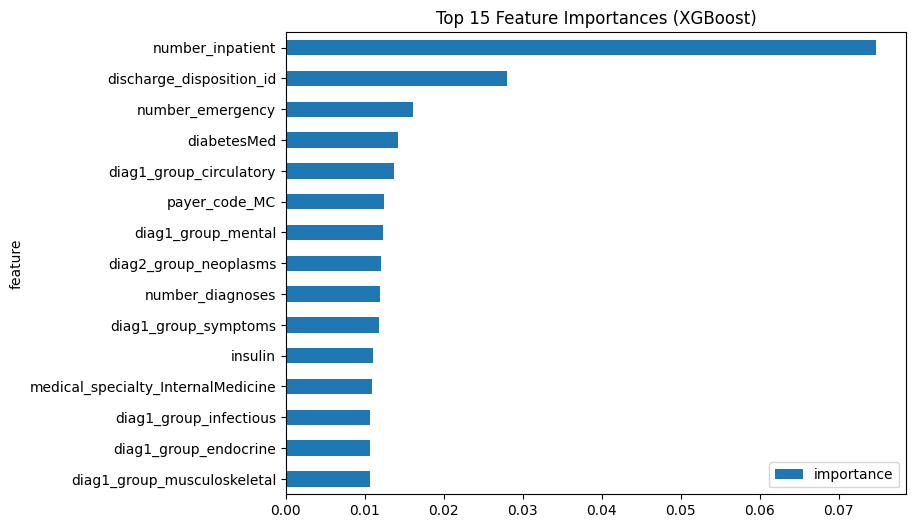

In [46]:
import matplotlib.pyplot as plt

importance_df.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()